# Counter-Strike Professional Game Probability Regression Model

In [69]:
# ── Standard Library ────────────────────────────────────────────────
import os
import random

# ── Core Data ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import polars as pl

from dataclasses import dataclass
from typing import Dict, Callable, Tuple, Any

# ── Visualization ───────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Sklearn ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss

# ── XGBoost ─────────────────────────────────────────────────────────
from xgboost import XGBClassifier

# ── PyCaret ─────────────────────────────────────────────────────────
from pycaret.classification import setup, compare_models, tune_model, predict_model, save_model

# ── PyTorch ─────────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ── Optuna ──────────────────────────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Weights & Biases ────────────────────────────────────────────────
import wandb

# ── Persistence ─────────────────────────────────────────────────────
import joblib

# ── Reproducibility ─────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Data Loading, Exploration And Cleanup

Data source: https://www.kaggle.com/datasets/gabrieltardochi/counter-strike-global-offensive-matches

In [46]:
def load_data(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    return pd.read_csv(path)

data_path = 'data/csgo_games.csv'

df = load_data(data_path)

In [47]:
df

,match_date,team_1,team_2,t1_points,t2_points,t1_world_rank,t2_world_rank,t1_h2h_win_perc,t2_h2h_win_perc,winner,...,t2_player5_dpr,t2_player5_spr,t2_player5_opk_ratio,t2_player5_opk_rating,t2_player5_wins_perc_after_fk,t2_player5_fk_perc_in_wins,t2_player5_multikill_perc,t2_player5_rating_at_least_one_perc,t2_player5_is_sniper,t2_player5_clutch_win_perc
0,2016-12-18,CLOUD9,HELLRAISERS,13,16,9,20,0.500000,0.500000,t2,...,0.63,0.10,1.05,0.92,0.733,0.104,0.147018,0.528,False,0.666667
1,2016-12-18,IMMORTALS,G2,17,19,13,10,0.500000,0.500000,t2,...,0.69,0.09,0.85,0.96,0.739,0.147,0.135810,0.438,True,0.406250
2,2016-12-18,MOUSESPORTS,IMMORTALS,16,3,12,13,0.500000,0.500000,t1,...,0.67,0.07,0.79,0.94,0.723,0.129,0.148257,0.526,False,0.733333
3,2016-12-18,DIGNITAS,G2,16,9,6,10,0.416667,0.583333,t1,...,0.69,0.09,0.85,0.96,0.739,0.147,0.135810,0.438,True,0.406250
4,2016-12-18,OPTIC,HELLRAISERS,16,10,4,20,0.500000,0.500000,t1,...,0.63,0.10,1.05,0.92,0.733,0.104,0.147018,0.528,False,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3782,2020-01-25,VIRTUS.PRO,CLOUD9,0,2,19,17,0.500000,0.500000,t2,...,0.67,0.11,0.80,0.95,0.681,0.121,0.130481,0.444,False,0.777778
3783,2020-01-24,HEROIC,MAD LIONS,10,16,16,18,0.333333,0.666667,t2,...,0.65,0.08,0.64,0.80,0.811,0.082,0.095975,0.250,False,0.625000
3784,2020-01-19,HEROIC,FORZE,0,2,16,13,0.857143,0.142857,t2,...,0.63,0.09,0.89,0.92,0.747,0.113,0.154618,0.635,False,0.709677
3785,2020-01-19,CR4ZY,FORZE,0,2,20,13,0.538462,0.461538,t2,...,0.63,0.09,0.89,0.92,0.747,0.113,0.154618,0.635,False,0.709677


In [48]:
df.shape

(3787, 170)

In [49]:
df.describe()

,t1_points,t2_points,t1_world_rank,t2_world_rank,t1_h2h_win_perc,t2_h2h_win_perc,t1_player1_rating,t1_player1_impact,t1_player1_kdr,t1_player1_dmr,...,t2_player5_apr,t2_player5_dpr,t2_player5_spr,t2_player5_opk_ratio,t2_player5_opk_rating,t2_player5_wins_perc_after_fk,t2_player5_fk_perc_in_wins,t2_player5_multikill_perc,t2_player5_rating_at_least_one_perc,t2_player5_clutch_win_perc
count,3787.000000,3787.000000,3787.000000,3787.000000,3787.000000,3787.000000,3787.000000,3787.000000,3787.000000,3787.000000,...,3787.000000,3787.000000,3787.000000,3787.000000,3787.000000,3786.000000,3787.000000,3787.000000,3787.000000,3787.000000
mean,7.829945,7.687351,8.836810,9.836546,0.517780,0.482220,1.185255,1.230552,1.211069,82.257882,...,0.134177,0.668492,0.085883,0.881109,0.933752,0.743385,0.123172,0.142620,0.479368,0.593293
std,6.869174,6.894263,5.550307,5.616128,0.228813,0.228813,0.067781,0.106033,0.112633,4.527635,...,0.019367,0.034841,0.015337,0.174513,0.072848,0.048824,0.025787,0.015386,0.099792,0.143225
min,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.970000,0.880000,0.870000,63.200000,...,0.040000,0.530000,0.020000,0.000000,0.490000,0.375000,0.000000,0.059829,0.000000,0.000000
25%,2.000000,2.000000,4.000000,5.000000,0.389566,0.333333,1.140000,1.160000,1.130000,79.200000,...,0.120000,0.650000,0.080000,0.770000,0.890000,0.715250,0.105000,0.132526,0.417000,0.500000
50%,6.000000,5.000000,8.000000,10.000000,0.500000,0.500000,1.180000,1.230000,1.200000,82.400000,...,0.130000,0.670000,0.090000,0.870000,0.930000,0.747000,0.121000,0.143365,0.483000,0.600000
75%,16.000000,16.000000,13.000000,15.000000,0.666667,0.610434,1.230000,1.300000,1.270000,85.300000,...,0.150000,0.690000,0.100000,0.980000,0.980000,0.775000,0.139000,0.152723,0.544000,0.676471
max,34.000000,34.000000,22.000000,22.000000,1.000000,1.000000,1.440000,1.790000,1.600000,98.700000,...,0.210000,0.810000,0.150000,2.120000,1.200000,1.000000,0.221000,0.194529,0.802000,1.000000


In [50]:
df[df.isnull().any(axis=1)]

,match_date,team_1,team_2,t1_points,t2_points,t1_world_rank,t2_world_rank,t1_h2h_win_perc,t2_h2h_win_perc,winner,...,t2_player5_dpr,t2_player5_spr,t2_player5_opk_ratio,t2_player5_opk_rating,t2_player5_wins_perc_after_fk,t2_player5_fk_perc_in_wins,t2_player5_multikill_perc,t2_player5_rating_at_least_one_perc,t2_player5_is_sniper,t2_player5_clutch_win_perc
383,2016-09-14,ENVY,MOUSESPORTS,9,16,11,16,0.461538,0.538462,t2,...,0.72,0.11,0.74,0.90,0.755,0.127,0.134255,0.400,False,0.538462
731,2016-03-31,MOUSESPORTS,NIP,1,2,10,9,0.153846,0.846154,t2,...,0.72,0.05,0.00,0.49,NaN,0.000,0.070175,0.000,False,1.000000
735,2016-03-30,NIP,LUMINOSITY,5,16,9,4,0.600000,0.400000,t2,...,0.63,0.08,0.93,0.97,0.764,0.120,0.168067,0.557,False,0.681818
1994,2018-11-13,HEROIC,HELLRAISERS,14,16,19,15,1.000000,0.000000,t2,...,0.68,0.09,0.79,0.89,0.693,0.108,0.121581,0.300,False,0.565217


#### Only 4 matches have missing values, can safely drop without thinking about filling strategies

In [51]:
df = df.dropna()

df.shape

(3783, 170)

### Leakage Check

We need to delete anything that is avaiable only POST game and is not the target, e.g. game points. We will also be deleting columns that don't bring any valuable information.

- date: not a usefull info
- team names: rosters change, models performance would worsen over time quicker
- points: not avaiable pre-match
- leaving player ratings as they are calculated over a 3 month period BEFORE the game

In [52]:
# manually inspecting each column :(((
for col in df.columns:
    print(col)
    

match_date
team_1
team_2
t1_points
t2_points
t1_world_rank
t2_world_rank
t1_h2h_win_perc
t2_h2h_win_perc
winner
t1_player1_rating
t1_player1_impact
t1_player1_kdr
t1_player1_dmr
t1_player1_kpr
t1_player1_apr
t1_player1_dpr
t1_player1_spr
t1_player1_opk_ratio
t1_player1_opk_rating
t1_player1_wins_perc_after_fk
t1_player1_fk_perc_in_wins
t1_player1_multikill_perc
t1_player1_rating_at_least_one_perc
t1_player1_is_sniper
t1_player1_clutch_win_perc
t1_player2_rating
t1_player2_impact
t1_player2_kdr
t1_player2_dmr
t1_player2_kpr
t1_player2_apr
t1_player2_dpr
t1_player2_spr
t1_player2_opk_ratio
t1_player2_opk_rating
t1_player2_wins_perc_after_fk
t1_player2_fk_perc_in_wins
t1_player2_multikill_perc
t1_player2_rating_at_least_one_perc
t1_player2_is_sniper
t1_player2_clutch_win_perc
t1_player3_rating
t1_player3_impact
t1_player3_kdr
t1_player3_dmr
t1_player3_kpr
t1_player3_apr
t1_player3_dpr
t1_player3_spr
t1_player3_opk_ratio
t1_player3_opk_rating
t1_player3_wins_perc_after_fk
t1_player3_fk_per

In [53]:
del_cols_keywords = ['date', 'team_1', 'team_2', 'points']

# dropping the cols
df = df.drop(columns=[col for col in df.columns if any(keyword in col for keyword in del_cols_keywords)])

df.columns

Index(['t1_world_rank', 't2_world_rank', 't1_h2h_win_perc', 't2_h2h_win_perc',
       'winner', 't1_player1_rating', 't1_player1_impact', 't1_player1_kdr',
       't1_player1_dmr', 't1_player1_kpr',
       ...
       't2_player5_dpr', 't2_player5_spr', 't2_player5_opk_ratio',
       't2_player5_opk_rating', 't2_player5_wins_perc_after_fk',
       't2_player5_fk_perc_in_wins', 't2_player5_multikill_perc',
       't2_player5_rating_at_least_one_perc', 't2_player5_is_sniper',
       't2_player5_clutch_win_perc'],
      dtype='object', length=165)

### Checking Variances and Correlations
Can drop low variance columns and one column of a highly correlated pair

In [55]:
num_df = df.select_dtypes(include="number")

num_df.var().sort_values(ascending=True)


t1_player3_multikill_perc     0.000184
t2_player3_multikill_perc     0.000187
t2_player2_multikill_perc     0.000190
t2_player4_multikill_perc     0.000192
t1_player4_multikill_perc     0.000194
                               ...    
t1_player2_dmr               18.824156
t1_player1_dmr               20.472285
t2_player1_dmr               22.422759
t1_world_rank                30.809558
t2_world_rank                31.547965
Length: 154, dtype: float64

In [59]:
corr = num_df.corr()

mask = np.triu(np.ones(corr.shape), k=1).astype(bool)

pairs = (
corr.where(mask)
.stack()
.reset_index()
)
pairs.columns = ["col_1", "col_2", "corr"]

pairs["abs_corr"] = pairs["corr"].abs()
pairs = pairs.sort_values("abs_corr", ascending=False).reset_index(drop=True)

pairs

,col_1,col_2,corr,abs_corr
0,t1_h2h_win_perc,t2_h2h_win_perc,-1.000000,1.000000
1,t1_player1_kpr,t1_player1_multikill_perc,0.923770,0.923770
2,t2_player1_kpr,t2_player1_multikill_perc,0.923757,0.923757
3,t2_player5_kpr,t2_player5_multikill_perc,0.915217,0.915217
4,t1_player5_kpr,t1_player5_multikill_perc,0.912656,0.912656
...,...,...,...,...
11776,t2_h2h_win_perc,t2_player1_clutch_win_perc,-0.000012,0.000012
11777,t1_player5_opk_ratio,t2_player1_kdr,-0.000012,0.000012
11778,t2_player2_rating_at_least_one_perc,t2_player3_fk_perc_in_wins,-0.000011,0.000011
11779,t1_player1_kdr,t1_player4_fk_perc_in_wins,-0.000009,0.000009


Dropping Team 2 head to head win percentage as its just 1 - t1_h2h_win_perc. Will leave highly correlated player stats (a good player will have good stats across the board) as it shouldn't negatively impact nets or xgboost, although will prepare a simple data version with just player rating (some unknown combination of all the stats) as it might work better for simple models (e.g lin reg).

In [61]:
df = df.drop(columns=['t2_h2h_win_perc'])

In [65]:
leave_cols_keywords = ['world_rank', 't1_h2h_win_perc', 'winner', 'rating']
remove_cols_keywords = ['rating_at_least_one_perc', 'opk_rating']

df_simple = df[[col for col in df.columns if any(keyword in col for keyword in leave_cols_keywords) and not any(keyword in col for keyword in remove_cols_keywords)]]

df_simple.columns

Index(['t1_world_rank', 't2_world_rank', 't1_h2h_win_perc', 'winner',
       't1_player1_rating', 't1_player2_rating', 't1_player3_rating',
       't1_player4_rating', 't1_player5_rating', 't2_player1_rating',
       't2_player2_rating', 't2_player3_rating', 't2_player4_rating',
       't2_player5_rating'],
      dtype='object')

<Axes: >

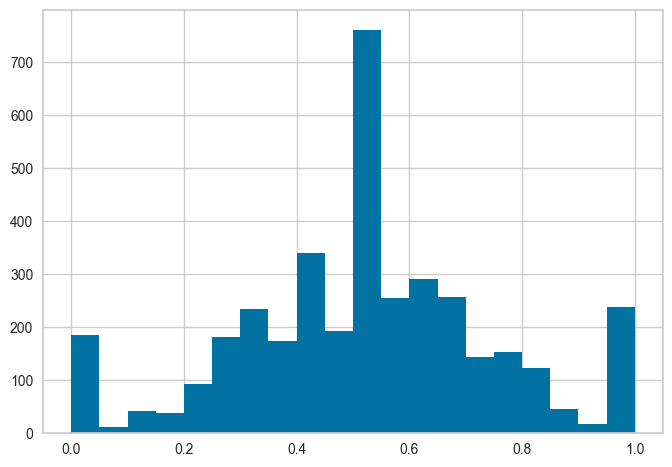

In [67]:
df['t1_h2h_win_perc'].hist(bins=20)

t1_h2h_win_perc might be a problematic feature, teams that faced each other only once will have either 1.0 or 0.0 which is an unreasonably strong signal. There is no info about the number of matches between them. Solution: prepare different versions and include them in the hyperparam search.

In [ ]:
TARGET_COL = "winner"
H2H_COL = "t1_h2h_win_perc"
SEED = 42


def make_h2h_versions(df, h2h_col=H2H_COL):
    out = {}

    out["raw"] = df.copy()

    d = df.copy()
    if h2h_col in d.columns:
        d = d.drop(columns=[h2h_col])
    out["drop"] = d

    d = df.copy()
    if h2h_col in d.columns:
        d[h2h_col] = d[h2h_col].astype(float).clip(0.05, 0.95)
    out["clip_05_95"] = d

    d = df.copy()
    if h2h_col in d.columns:
        d[h2h_col] = d[h2h_col].astype(float).clip(0.10, 0.90)
    out["clip_10_90"] = d

    d = df.copy()
    if h2h_col in d.columns:
        p = d[h2h_col].astype(float)
        d["h2h_signed"] = p - 0.5
        d["h2h_abs_strength"] = (p - 0.5).abs()
        d["h2h_is_extreme"] = ((p <= 0.01) | (p >= 0.99)).astype(int)
        d = d.drop(columns=[h2h_col])
    out["signed_extreme"] = d

    return out


def build_dataset_variants(base_datasets, target_col=TARGET_COL, h2h_col=H2H_COL):
    variants = {}
    rows = []

    for base_name, base_df in base_datasets.items():
        h2h_versions = make_h2h_versions(base_df, h2h_col=h2h_col)

        for h2h_name, d in h2h_versions.items():
            name = f"{base_name}__h2h_{h2h_name}"
            d = d.dropna(subset=[target_col]).reset_index(drop=True)
            variants[name] = d

            rows.append({
                "dataset_name": name,
                "rows": len(d),
                "cols": d.shape[1],
                "feature_cols": d.shape[1] - 1,
                "has_h2h_raw": h2h_col in d.columns,
            })

    manifest = pd.DataFrame(rows).sort_values("dataset_name").reset_index(drop=True)
    return variants, manifest


def split_dataset(d, target_col=TARGET_COL, test_size=0.20, valid_size=0.20, seed=SEED, stratify=True):
    X = d.drop(columns=[target_col])
    y = d[target_col].astype(int)

    s = y if stratify else None
    X_train_valid, X_test, y_train_valid, y_test = train_test_split(
        X, y, test_size=test_size, random_state=seed, stratify=s
    )

    rel_valid_size = valid_size / (1.0 - test_size)
    s_tv = y_train_valid if stratify else None
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_valid, y_train_valid, test_size=rel_valid_size, random_state=seed, stratify=s_tv
    )

    return X_train, X_valid, X_test, y_train, y_valid, y_test


def prepare_for_model(d, model_family, target_col=TARGET_COL, test_size=0.20, valid_size=0.20, seed=SEED):
    X_train, X_valid, X_test, y_train, y_valid, y_test = split_dataset(
        d, target_col=target_col, test_size=test_size, valid_size=valid_size, seed=seed, stratify=True
    )

    preprocess = {"model_family": model_family}

    if model_family in {"nn", "logreg", "svm", "linear"}:
        scaler = StandardScaler()
        num_cols = X_train.select_dtypes(include="number").columns

        X_train = X_train.copy()
        X_valid = X_valid.copy()
        X_test = X_test.copy()

        X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
        X_valid[num_cols] = scaler.transform(X_valid[num_cols])
        X_test[num_cols] = scaler.transform(X_test[num_cols])

        preprocess["scaler"] = scaler
        preprocess["scaled_cols"] = list(num_cols)

    elif model_family not in {"xgb", "rf", "tree", "catboost", "lgbm"}:
        raise ValueError("Unknown model_family")

    return {
        "X_train": X_train,
        "X_valid": X_valid,
        "X_test": X_test,
        "y_train": y_train,
        "y_valid": y_valid,
        "y_test": y_test,
        "preprocess": preprocess,
    }


# -------- Usage --------
base_datasets = {
    "full": df.copy(),
    "simple": df_simple.copy(),
}

variants, manifest = build_dataset_variants(base_datasets)
manifest.head(20)

# Example:
# prep_nn = prepare_for_model(variants["full__h2h_clip_05_95"], model_family="nn")
# prep_xgb = prepare_for_model(variants["simple__h2h_raw"], model_family="xgb")